# Bivariate Analysis

**Bivariate** means looking at **two columns at a time** to find relationships.

The key question here is — *what affects flight price?*

I am using all 3 datasets in this notebook:
- `flights_merged.csv` → flights + users combined (from notebook 02)
- `hotels.csv` → loaded fresh for hotel analysis

**Charts I will make:**
1. Box Plot — Price by Flight Type
2. Scatter Plot — Price vs Distance
3. Line Graph — Average Price Trend Over Months
4. Bar Chart — Average Price by Gender
5. Pie Chart — Hotel Bookings Share by City
6. Bar Chart — Average Hotel Price by Hotel Name

# Setup - loading all 3 datasets

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

# finding project root
BASE_DIR = Path(os.getcwd())
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

# flights + users (already merged and cleaned in notebook 02)
df = pd.read_csv(BASE_DIR / "data" / "processed" / "flights_merged.csv")

# hotels — loading fresh from raw folder
hotels = pd.read_csv(BASE_DIR / "data" / "raw" / "hotels.csv")

# converting date column back to datetime after loading from CSV
df["date"] = pd.to_datetime(df["date"])

print("flights+users rows:", len(df))
print("hotels rows       :", len(hotels))

flights+users rows: 271888
hotels rows       : 40552


All 3 datasets are loaded — flights, users (inside df), and hotels separately.

## Graph 1 - Box Plot : Price by Flight Type

**Why this matters:** Flight type is the most important feature for my regression model.
A box plot shows the price spread for each class clearly.

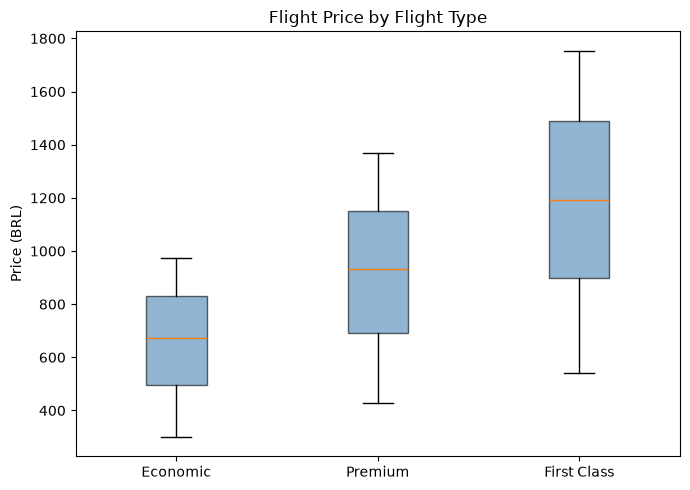

flightType
economic       658.44
firstClass    1181.07
premium        920.39
Name: price, dtype: float64


In [5]:
# separating price values for each flight type
economic   = df[df["flightType"] == "economic"]["price"]
premium    = df[df["flightType"] == "premium"]["price"]
firstclass = df[df["flightType"] == "firstClass"]["price"]

plt.figure(figsize=(7, 5))

# drawing box plot — each box shows min, Q1, median, Q3, max
plt.boxplot(
    [economic, premium, firstclass],
    patch_artist=True,
    boxprops=dict(facecolor="steelblue", alpha=0.6)
)

# setting x-axis labels separately — works in all matplotlib versions
plt.xticks([1, 2, 3], ["Economic", "Premium", "First Class"])

plt.title("Flight Price by Flight Type")
plt.ylabel("Price (BRL)")
plt.tight_layout()
plt.show()

# printing average price per class
print(df.groupby("flightType")["price"].mean().round(2))

First Class is clearly the most expensive and Economic the cheapest flight type will be the strongest feature in my model.

## Graph 2 - Scatter Plot : Price vs Distance

**Why this matters:** I want to see if longer flights cost more.
A scatter plot puts distance on x-axis and price on y-axis — each dot is one flight.

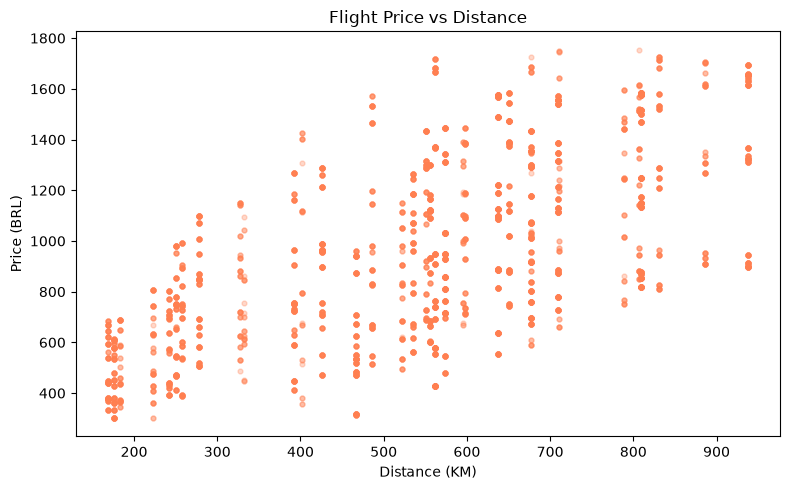

Correlation between price and distance: 0.642


In [6]:
# taking a sample of 4000 rows so the plot is not too heavy
sample = df.sample(4000, random_state=42)

plt.figure(figsize=(8, 5))

plt.scatter(sample["distance"], sample["price"], alpha=0.3, color="coral", s=12)

plt.title("Flight Price vs Distance")
plt.xlabel("Distance (KM)")
plt.ylabel("Price (BRL)")
plt.tight_layout()
plt.show()

# checking correlation between price and distance
corr = df["price"].corr(df["distance"])
print("Correlation between price and distance:", round(corr, 3))

There is a positive relationship between distance and price longer flights tend to cost more, confirmed by the correlation score.

## Graph 3 — Line Graph : Average Flight Price per Month

**Why this matters:** Prices may go up in certain months (holidays, peak season).
This graph uses the `date` column to show price trends over time.

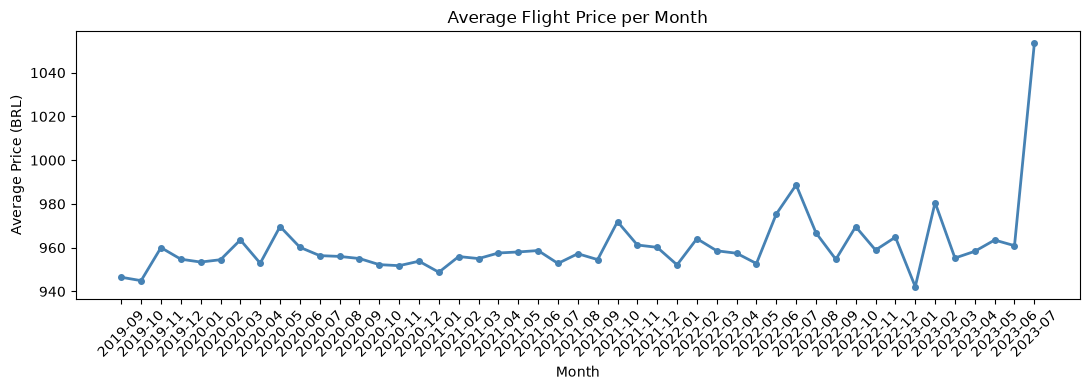

In [7]:
# extracting year-month from the date column
df["year_month"] = df["date"].dt.to_period("M").astype(str)

# calculating average price for each month
monthly_avg = df.groupby("year_month")["price"].mean().reset_index()

plt.figure(figsize=(11, 4))

plt.plot(monthly_avg["year_month"], monthly_avg["price"],
         marker="o", color="steelblue", linewidth=2, markersize=4)

plt.title("Average Flight Price per Month")
plt.xlabel("Month")
plt.ylabel("Average Price (BRL)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Flight prices stay fairly stable across months with small dips and peaks there is no strong seasonal pattern in this dataset.

## Graph 4 - Bar Chart : Average Flight Price by Gender

**Why this matters:** This uses the `users.csv` data (gender column) merged into flights.
I want to check if male, female or unspecified travellers pay different prices on average.

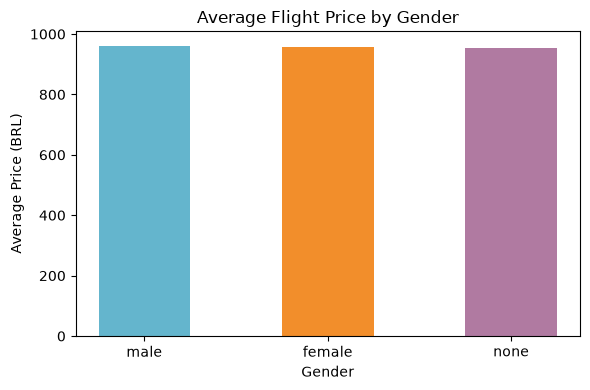

   gender       price
1    male  960.964715
0  female  956.584476
2    none  954.510078


In [8]:
# calculating average price for each gender group
avg_by_gender = df.groupby("gender")["price"].mean().reset_index()
avg_by_gender = avg_by_gender.sort_values("price", ascending=False)

plt.figure(figsize=(6, 4))

plt.bar(avg_by_gender["gender"], avg_by_gender["price"],
        color=["#64B5CD", "#F28E2B", "#B07AA1"], width=0.5)

plt.title("Average Flight Price by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Price (BRL)")
plt.tight_layout()
plt.show()

print(avg_by_gender)

All three gender groups pay almost the same average price gender alone does not influence how much a flight costs.

## Graph 5 - Pie Chart : Hotel Bookings Share by City

**Why this matters:** This uses the `hotels.csv` dataset to understand where travellers stay.
A pie chart shows what percentage of all hotel bookings each city gets.

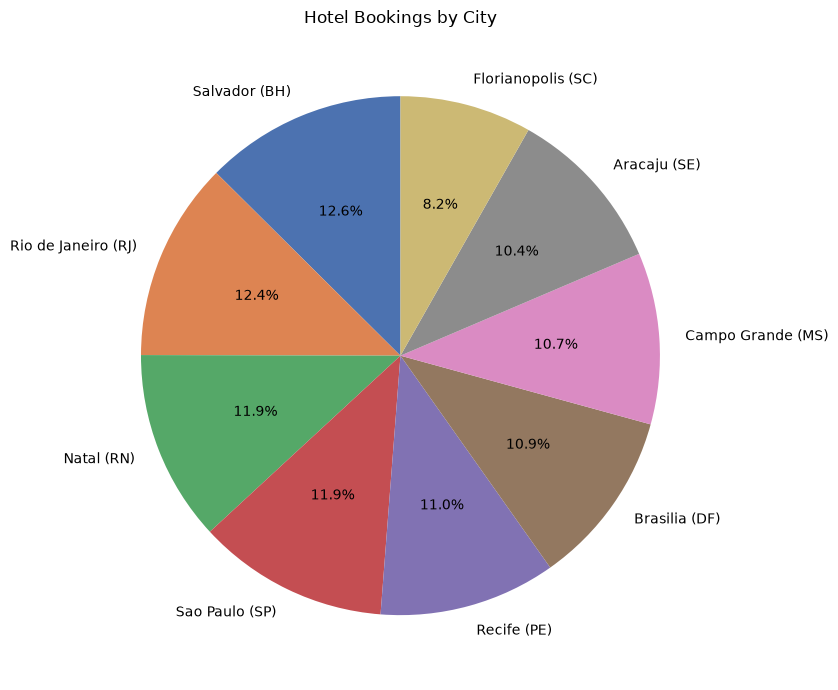

place
Salvador (BH)          5094
Rio de Janeiro (RJ)    5029
Natal (RN)             4829
Sao Paulo (SP)         4828
Recife (PE)            4467
Brasilia (DF)          4437
Campo Grande (MS)      4333
Aracaju (SE)           4205
Florianopolis (SC)     3330
Name: count, dtype: int64


In [9]:
# counting total hotel bookings per city
city_counts = hotels["place"].value_counts()

plt.figure(figsize=(8, 7))

plt.pie(
    city_counts.values,
    labels=city_counts.index,
    autopct="%1.1f%%",   # shows percentage on each slice
    startangle=90,
    colors=["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3",
            "#937860","#DA8BC3","#8C8C8C","#CCB974"]
)

plt.title("Hotel Bookings by City")
plt.tight_layout()
plt.show()

print(city_counts)

A few cities take the largest share of hotel bookings — travellers have clear destination preferences.

## Graph 6 - Bar Chart : Average Hotel Price per Night by Hotel Name

**Why this matters:** This uses `hotels.csv` to compare pricing across different hotels.
Knowing which hotels are expensive vs affordable is useful for a recommendation model.

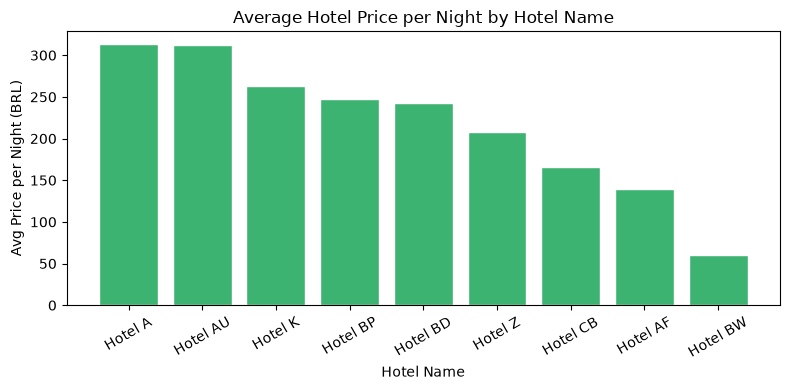

       name   price
0   Hotel A  313.02
1  Hotel AU  312.83
2   Hotel K  263.41
3  Hotel BP  247.62
4  Hotel BD  242.88
5   Hotel Z  208.04
6  Hotel CB  165.99
7  Hotel AF  139.10
8  Hotel BW   60.39


In [10]:
# average price per night for each hotel, sorted highest to lowest
avg_hotel_price = hotels.groupby("name")["price"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 4))

plt.bar(avg_hotel_price["name"], avg_hotel_price["price"],
        color="mediumseagreen", edgecolor="white")

plt.title("Average Hotel Price per Night by Hotel Name")
plt.xlabel("Hotel Name")
plt.ylabel("Avg Price per Night (BRL)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(avg_hotel_price)

There is a clear price difference between hotels the most expensive hotel costs roughly 5x more per night than the cheapest one.

## Summary

| Graph | Chart Type | Datasets Used | Key Finding |
|---|---|---|---|
| Price by Flight Type | Box Plot | flights | First class costs the most |
| Price vs Distance | Scatter Plot | flights | Longer distance = higher price |
| Monthly Price Trend | Line Graph | flights | No strong seasonal pattern |
| Price by Gender | Bar Chart | flights + users | Gender doesn't affect price |
| Hotel Bookings by City | Pie Chart | hotels | Few cities dominate bookings |
| Hotel Price by Name | Bar Chart | hotels | Big price gap between hotels |